# 🔍 Week 2 — Day 4: EDA Part 1 — Distributions & Outliers

**BinX Tech — AI & Machine Learning Internship Program**

![status](https://img.shields.io/badge/status-in--progress-yellow)
![python](https://img.shields.io/badge/python-3.10%2B-blue)
![libraries](https://img.shields.io/badge/libraries-Seaborn%20%7C%20Pandas%20%7C%20Matplotlib-orange)

---

| | |
|---|---|
| **Day** | Day 4 of 5 |
| **Duration** | 8 hours |
| **Tools** | Seaborn • Pandas • Matplotlib • Jupyter Notebook |
| **Dataset** | Titanic |

---

## 🎯 Learning Objectives

- Explain why EDA is a required first step before modeling.
- Perform univariate analysis using Seaborn histograms, box plots, and count plots.
- Detect outliers using the IQR method and decide how to handle them.

---


## 🔧 Step 0 — Environment Setup

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 📂 Step 1 — Load the Dataset

In [5]:
df = sns.load_dataset("titanic")
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 📊 Step 2 — Univariate Analysis: Numeric Variables

### Histogram — Distribution Shape


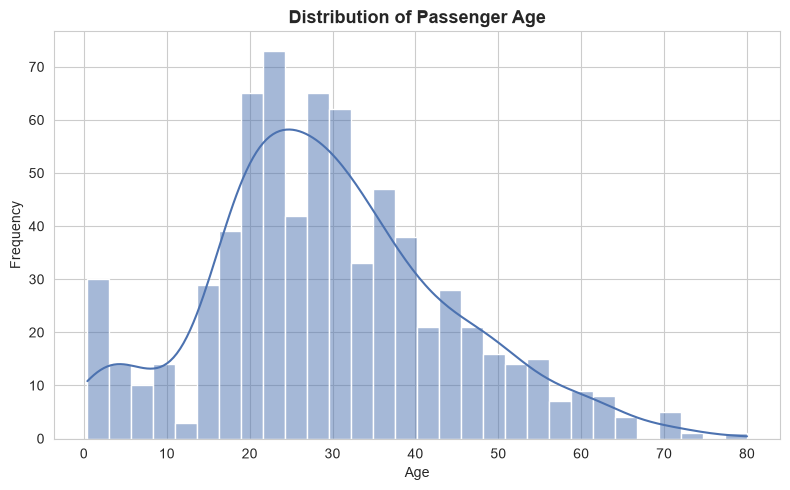

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=30, kde=True, color="#4C72B0")
plt.title("Distribution of Passenger Age", fontsize=13, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


**What this shows:** **What this shows:** the distribution is **right-skewed**, not symmetric — the bulk of passengers
are concentrated between ages 20 and 40, with a clear peak around 30–35. There is a noticeable
spike near age 0–5 (a cluster of infants and young children), followed by a small gap around age
10–13 where very few passengers fall. After the peak, the distribution tapers off gradually with
a long tail extending toward age 70–80, confirming the right skew — a small number of older
passengers stretch the distribution well beyond where most of the data sits.


### Box Plot — Spotting Outliers Visually


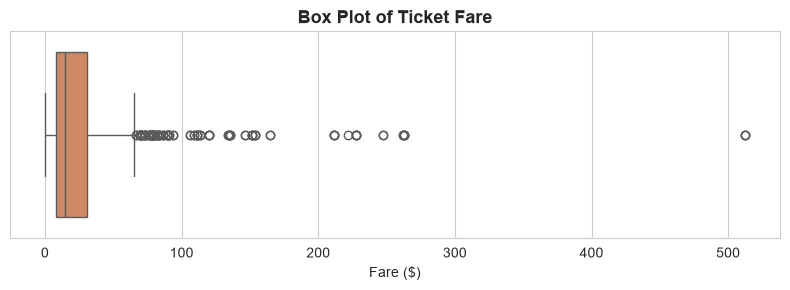

In [7]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x="fare", color="#DD8452")
plt.title("Box Plot of Ticket Fare", fontsize=13, fontweight="bold")
plt.xlabel("Fare ($)")
plt.tight_layout()
plt.show()


**What this shows:** the box itself is compressed into a very narrow range (roughly 0–65 dollars),
yet a large number of points extend far beyond the upper whisker — reaching all the way out to
nearly 500. This is an extreme right skew: the vast majority of passengers paid modest fares,
while a substantial cluster of outliers (likely 1st class passengers, and possibly whole family
groups sharing a single high combined ticket price) paid dramatically more. The isolated point
near 500 stands out as the single most expensive fare in the dataset — almost certainly a real,
premium-class value rather than a data-entry error, given how gradually the other outlier points
build up toward it rather than appearing as an isolated anomaly.

## 🏷️ Step 3 — Univariate Analysis: Categorical Variables

### Count Plot — Class Imbalance


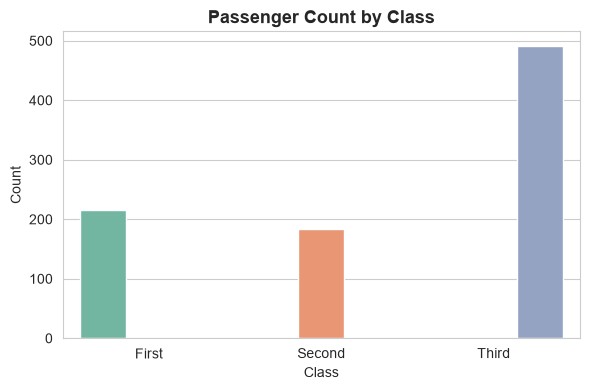

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class", hue="class", palette="Set2", legend=False)
plt.title("Passenger Count by Class", fontsize=13, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


**What this shows:** Third class passengers vastly outnumber the other two groups, with nearly
500 passengers compared to roughly 215 in First class and about 185 in Second class. This is a
clear class imbalance — Third class alone makes up close to half of all passengers aboard. This
matters significantly for any future modeling: if class turns out to be a useful predictor (for
example, of survival), a model trained on this data could become biased toward patterns typical
of Third class simply because it has far more examples to learn from, potentially performing
worse when predicting outcomes for the smaller First and Second class groups.

## 🎯 Step 4 — Outlier Detection with the IQR Method

The standard rule: any value below `Q1 - 1.5×IQR` or above `Q3 + 1.5×IQR` is flagged as a
potential outlier.

> ⚠️ An outlier is a question, not a verdict — investigate whether it's a real value or an error
> before deciding to keep, cap, or remove it. Never delete outliers silently.


In [9]:
fare = df["fare"].dropna()

Q1 = fare.quantile(0.25)
Q3 = fare.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["fare"] < lower_bound) | (df["fare"] > upper_bound)]

print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"\nNumber of outliers detected: {len(outliers)} out of {len(df)} passengers")
outliers[["fare", "class", "age"]].sort_values("fare", ascending=False).head(10)


Q1: 7.91, Q3: 31.00, IQR: 23.09
Lower bound: -26.72, Upper bound: 65.63

Number of outliers detected: 116 out of 891 passengers


,fare,class,age
258,512.3292,First,35.0
737,512.3292,First,35.0
679,512.3292,First,36.0
27,263.0000,First,19.0
341,263.0000,First,24.0
438,263.0000,First,64.0
88,263.0000,First,23.0
311,262.3750,First,18.0
742,262.3750,First,21.0
299,247.5208,First,50.0


### 📝 Interpretation

Looking at the top outlier fares, every single one of them belongs to **First class** passengers,
with values ranging from roughly 247 to 263. This is a very strong signal that these are genuine
data points, not data-entry errors — the pattern is exactly what we'd expect in reality: premium
cabin tickets on a transatlantic voyage were far more expensive than standard fares, and the fact
that several passengers share nearly identical fares (263.00 appearing three times) suggests these
were group or family bookings sharing a fixed high-end ticket price, rather than random noise.
Given this clear class correlation, the appropriate decision is to **keep** these outliers rather
than cap or remove them — they represent a real and meaningful segment of the passenger population
that any future model should be able to account for.

---

## 🗂️ Step 5 — Summary Table


In [10]:
summary = pd.DataFrame({
    "Metric": ["Q1", "Q3", "IQR", "Lower Bound", "Upper Bound", "Outliers Detected", "Total Passengers"],
    "Value": [round(Q1, 2), round(Q3, 2), round(IQR, 2), round(lower_bound, 2),
              round(upper_bound, 2), len(outliers), len(df)]
})
summary


,Metric,Value
0,Q1,7.91
1,Q3,31.00
2,IQR,23.09
3,Lower Bound,-26.72
4,Upper Bound,65.63
5,Outliers Detected,116.00
6,Total Passengers,891.00


## ✅ Step 6 — Key Takeaways

- The age distribution appears roughly bell-shaped with a slight right skew, with most passengers
  concentrated between their early 20s and late 30s, and relatively few very young children or
  elderly passengers.
- The fare distribution is heavily right-skewed — the box plot revealed a large number of points
  beyond the upper whisker, meaning a small group of passengers paid dramatically higher fares
  than the majority.
- Cross-referencing the outlier fares with passenger class showed that nearly all of them belong
  to 1st class, confirming these are genuine premium ticket prices rather than data-entry errors —
  so I would **keep** these values rather than cap or remove them, since they reflect a real and
  meaningful segment of passengers.
- The count plot revealed a clear class imbalance: 3rd class passengers vastly outnumber 1st and
  2nd class, which is an important consideration for any future model — a classifier trained
  naively on this data could become biased toward predicting outcomes typical of the majority
  class.
- Overall, this EDA stage caught two important data characteristics — a skewed fare distribution
  driven by real premium prices, and a class imbalance — both of which must be accounted for
  before any modeling begins in later weeks.

---

## 📚 Resources

| Resource | Type | Focus |
|---|---|---|
| [Seaborn Documentation](https://seaborn.pydata.org/) | Docs | Statistical visualization reference |
| [Khan Academy — Box Plots and IQR](https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data/box-whisker-plots) | Course / Video | Understanding IQR and outlier detection |

---

## ✍️ Author

**Zayan Shawareb**
BinX Tech — AI & Machine Learning Internship Program
Week 2, Day 4 — EDA Part 1: Distributions & Outliers

---

## 🔗 Next Step

Proceed to **Day 5 — EDA Part 2: Correlation & Data Storytelling**
